In [1]:
import pandas as pd
import numpy as np
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Automobile Price Analysis in the Nigerian Used Car Market
The goal of this class work is to analyze a dataset of automobile listings to uncover insights into pricing trends, brand value, and factors influencing car prices in the Nigerian used car market.
The dataset contains details such as title, make, model, year, condition, transmission, and price.
1. Data Cleaning Phase
Objectives:
Before any analysis, the dataset must be cleaned to ensure reliability.
Steps & Questions:
Handle missing values


How many missing values exist in each column (make, model, year)?


Are there rows missing essential info like both make and model (likely unusable)?


In [2]:
df= pd.read_csv("data/automobile-price-analysis-in-nigeria-used-car-market.csv")
df

,title,make,model,year,condition,transmission,price
0,Lexus RX 350 FWD 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,"₦ 41,000,000"
1,Toyota Sequoia SR5 4dr SUV (4.7L 8cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,"₦ 4,650,000"
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,"₦ 6,600,000"
3,Toyota Corolla LE 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,"₦ 7,800,000"
4,Toyota Venza Limited 4dr Wagon AWD (3.5L 6cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,"₦ 13,000,000"
...,...,...,...,...,...,...,...
1995,Honda CR-V EX 4dr SUV AWD (2.4L 4cyl 5A) 2013 ...,Honda,CR-V EX,2013.0,foreign used,automatic,"₦ 16,500,000"
1996,Toyota RAV4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010.0,local used,automatic,"₦ 11,000,000"
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005.0,local used,automatic,"₦ 4,500,000"
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006.0,local used,automatic,"₦ 6,000,000"


In [3]:
df.head()

,title,make,model,year,condition,transmission,price
0,Lexus RX 350 FWD 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,"₦ 41,000,000"
1,Toyota Sequoia SR5 4dr SUV (4.7L 8cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,"₦ 4,650,000"
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,"₦ 6,600,000"
3,Toyota Corolla LE 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,"₦ 7,800,000"
4,Toyota Venza Limited 4dr Wagon AWD (3.5L 6cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,"₦ 13,000,000"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         2000 non-null   str    
 1   make          1990 non-null   str    
 2   model         1990 non-null   str    
 3   year          1990 non-null   float64
 4   condition     2000 non-null   str    
 5   transmission  1994 non-null   str    
 6   price         2000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 272.0 KB


In [5]:
df['price'].describe()

count             2000
unique             595
top       ₦ 13,000,000
freq                28
Name: price, dtype: object

In [6]:
df.isnull().sum()

title            0
make            10
model           10
year            10
condition        0
transmission     6
price            0
dtype: int64

In [7]:
#inspect unique values in columns
print(df['make'].unique())
print(df['condition'].unique())
print(df['transmission'].unique())

<ArrowStringArray>
[        'Lexus',        'Toyota',         'Mazda',           'Kia',
         'Honda',          'Ford',       'Hyundai', 'Mercedes-Benz',
          'Opel',           'BMW',     'Chevrolet',          'Land',
         'Acura',           'New',       'Peugeot',         'Dodge',
          'Jeep',        'Jaguar',        'Nissan',          'Mini',
    'Mitsubishi',       'Pontiac',           'JAC',      'Infiniti',
       'Changan',   'Rolls-Royce',    'Volkswagen',             nan,
       'Lincoln',           'GMC',          'Fiat',         'Volvo',
         'Scion',        'Subaru',         'Rover',           'JMC',
          'Audi',       'Renault',      'Chrysler',            'ZX',
       'Porsche']
Length: 41, dtype: str
<ArrowStringArray>
['foreign used', 'local used', 'brand new']
Length: 3, dtype: str
<ArrowStringArray>
['automatic', 'manual', nan]
Length: 3, dtype: str


In [8]:
df.describe()

,year
count,1990.000000
mean,2012.868844
std,5.923034
min,1958.000000
25%,2009.000000
50%,2013.000000
75%,2016.000000
max,2026.000000


In [9]:
#start cleaning inconsistent values
#clean columns name
df.rename(columns={
    "title": "Title",
    "make": "Make",
    "model": "Model",
    "year": "Year",
    "transmission": "Transmission",
    "condition": "Condition",
    "price": "Price"
}, inplace=True)

df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus RX 350 FWD 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,"₦ 41,000,000"
1,Toyota Sequoia SR5 4dr SUV (4.7L 8cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,"₦ 4,650,000"
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,"₦ 6,600,000"
3,Toyota Corolla LE 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,"₦ 7,800,000"
4,Toyota Venza Limited 4dr Wagon AWD (3.5L 6cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,"₦ 13,000,000"
...,...,...,...,...,...,...,...
1995,Honda CR-V EX 4dr SUV AWD (2.4L 4cyl 5A) 2013 ...,Honda,CR-V EX,2013.0,foreign used,automatic,"₦ 16,500,000"
1996,Toyota RAV4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010.0,local used,automatic,"₦ 11,000,000"
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005.0,local used,automatic,"₦ 4,500,000"
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006.0,local used,automatic,"₦ 6,000,000"


In [10]:
#clean incosistence values on Title
df['Title'] = (
    df['Title']
    .str.strip()
    .str.title()
    .str.replace(r"[\s-]+", " ", regex=True)
)
df['Title'].to_list()

['Lexus Rx 350 Fwd 2017 Blue',
 'Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003 Gray',
 'Toyota Solara 2008 Black',
 'Toyota Corolla Le 2004 Gray',
 'Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl 6A) 2014 Gray',
 'Lexus Is 250 2009 White',
 'Toyota Highlander Limited 2012 White',
 'Toyota Camry Se 4Dr Sedan (2.5L 4Cyl 6A) 2016 Silver',
 'Toyota Highlander Limited 2012 Black',
 'Mazda Cx 9 Sport 2013 Green',
 'Toyota Sienna 2025 Blue',
 'Toyota Sienna Xle 7 Passenger Mobility 2011 White',
 'Kia Sorento 4Dr Suv 2016 White',
 'Toyota Highlander Limited 4X4 2009 Black',
 'Toyota Highlander Limited 4Dr Suv Awd (3.5L 6Cyl 6A) 2015 Gray',
 'Lexus Lx 2017 White',
 'Toyota Rav4 2.5 Limited 2010 Black',
 'Toyota Highlander Xle Awd 2020 Gray',
 'Lexus Es 2014 Black',
 'Honda Accord Ex 4Dr Sedan Fwd (2.4L 4Cyl 2A) 2016 Burgundy',
 'Ford Kuga 2013 Blue',
 'Hyundai Sonata N Line 2021 Red',
 'Ford Explorer Limited 4Dr Suv Awd (3.5L 6Cyl 6A) 2016 Silver',
 'Ford Edge Se 4Dr Fwd (3.5L 6Cyl 6A) 2012 Bla

In [11]:
#Clean the price column
#Convert the price from strings like “₦ 25,500,000” to float (25500000.00).
#cleaning the price column

df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('₦', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus Rx 350 Fwd 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,41000000
1,Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,4650000
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,6600000
3,Toyota Corolla Le 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,7800000
4,Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,13000000
...,...,...,...,...,...,...,...
1995,Honda Cr V Ex 4Dr Suv Awd (2.4L 4Cyl 5A) 2013 ...,Honda,CR-V EX,2013.0,foreign used,automatic,16500000
1996,Toyota Rav4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010.0,local used,automatic,11000000
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005.0,local used,automatic,4500000
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006.0,local used,automatic,6000000


In [12]:
#Are there any outliers or invalid prices (too low/high)?

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
                    
IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df['Price'] < lower_bound) | (df['Price'] > upper_bound)

print(outliers.sum())
new_df = df[
    (df['Price'] > lower_bound) & (df['Price'] < upper_bound)
]
new_df

181


,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus Rx 350 Fwd 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,41000000
1,Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,4650000
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,6600000
3,Toyota Corolla Le 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,7800000
4,Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,13000000
...,...,...,...,...,...,...,...
1995,Honda Cr V Ex 4Dr Suv Awd (2.4L 4Cyl 5A) 2013 ...,Honda,CR-V EX,2013.0,foreign used,automatic,16500000
1996,Toyota Rav4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010.0,local used,automatic,11000000
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005.0,local used,automatic,4500000
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006.0,local used,automatic,6000000


In [13]:
new_df.dtypes

Title               str
Make                str
Model               str
Year            float64
Condition           str
Transmission        str
Price             int64
dtype: object

In [14]:
#drop the missing values in all dataset

new_df.dropna(inplace=True)

new_df.info()
new_df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 1804 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1804 non-null   str    
 1   Make          1804 non-null   str    
 2   Model         1804 non-null   str    
 3   Year          1804 non-null   float64
 4   Condition     1804 non-null   str    
 5   Transmission  1804 non-null   str    
 6   Price         1804 non-null   int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 234.7 KB


Title           0
Make            0
Model           0
Year            0
Condition       0
Transmission    0
Price           0
dtype: int64

In [15]:
#Standardize categorical columns
#Ensure consistent casing for make, model, condition, and transmission.
#e.g., “foreign used” to “Foreign Used”
#clean inconsistence values in condition

# new_df.replace({
#     "local used": "Local Used",
#     "foreign used": "Foreign Used",
#     "brand new": "Brand New",

# }, inplace=True)

# new_df['Condition']

columns=['Make','Model','Condition','Transmission']

for col in columns:
    df[col]=df[col].str.strip().str.title()
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus Rx 350 Fwd 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,41000000
1,Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,4650000
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,6600000
3,Toyota Corolla Le 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,7800000
4,Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,13000000
...,...,...,...,...,...,...,...
1995,Honda Cr V Ex 4Dr Suv Awd (2.4L 4Cyl 5A) 2013 ...,Honda,CR-V EX,2013.0,foreign used,automatic,16500000
1996,Toyota Rav4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010.0,local used,automatic,11000000
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005.0,local used,automatic,4500000
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006.0,local used,automatic,6000000


In [16]:
#fixing inconsistence naming under Make column

new_df['Make']=new_df['Make'].replace({
    "Mercedes Benz":"Mercedes-Benz",
    "Mercedes":"Mercedes-Benz",
    "Benz":"Mercedes-Benz"
})
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus Rx 350 Fwd 2017 Blue,Lexus,RX 350,2017.0,foreign used,automatic,41000000
1,Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003...,Toyota,Sequoia SR5,2003.0,local used,automatic,4650000
2,Toyota Solara 2008 Black,Toyota,Solara,2008.0,foreign used,automatic,6600000
3,Toyota Corolla Le 2004 Gray,Toyota,Corolla LE,2004.0,foreign used,automatic,7800000
4,Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl ...,Toyota,Venza Limited,2014.0,local used,automatic,13000000
...,...,...,...,...,...,...,...
1995,Honda Cr V Ex 4Dr Suv Awd (2.4L 4Cyl 5A) 2013 ...,Honda,CR-V EX,2013.0,foreign used,automatic,16500000
1996,Toyota Rav4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010.0,local used,automatic,11000000
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005.0,local used,automatic,4500000
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006.0,local used,automatic,6000000


In [17]:
#clean inconsistence values in Transmission

new_df.replace({
    "automatic": "Automatic",
    "manual": "Manual",


}, inplace=True)

new_df['Transmission']

0       Automatic
1       Automatic
2       Automatic
3       Automatic
4       Automatic
          ...    
1995    Automatic
1996    Automatic
1997    Automatic
1998    Automatic
1999       Manual
Name: Transmission, Length: 1804, dtype: str

In [18]:
#Convert year to integer
#Check for missing value on year.
new_df['Year'] = pd.to_numeric(new_df['Year'], errors='coerce')
new_df['Year'].isnull().sum()

np.int64(0)

In [19]:
#Remove rows where the year is clearly invalid (e.g., > 2025 or < 1980).

new_df = new_df[(new_df['Year'] >= 1980) & (new_df['Year'] <= 2025)]

new_df['Year'] = new_df['Year'].astype(int)
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus Rx 350 Fwd 2017 Blue,Lexus,RX 350,2017,foreign used,Automatic,41000000
1,Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003...,Toyota,Sequoia SR5,2003,local used,Automatic,4650000
2,Toyota Solara 2008 Black,Toyota,Solara,2008,foreign used,Automatic,6600000
3,Toyota Corolla Le 2004 Gray,Toyota,Corolla LE,2004,foreign used,Automatic,7800000
4,Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl ...,Toyota,Venza Limited,2014,local used,Automatic,13000000
...,...,...,...,...,...,...,...
1995,Honda Cr V Ex 4Dr Suv Awd (2.4L 4Cyl 5A) 2013 ...,Honda,CR-V EX,2013,foreign used,Automatic,16500000
1996,Toyota Rav4 2.5 Limited 2010 Red,Toyota,RAV4 2,2010,local used,Automatic,11000000
1997,Toyota Sienna 2005 Gray,Toyota,Sienna,2005,local used,Automatic,4500000
1998,Toyota Corolla 2006 Gray,Toyota,Corolla,2006,local used,Automatic,6000000


In [20]:
#Exploratory Data Analysis (EDA)
#Key Questions:
#What are the most common car brands (make)?
#Frequency count of each brand.

brand_count = new_df['Make'].value_counts().head(10)
print(brand_count)


Make
Toyota           787
Lexus            268
Mercedes-Benz    232
Honda            188
Hyundai           82
Ford              44
Nissan            25
Acura             23
Land              22
Kia               21
Name: count, dtype: int64


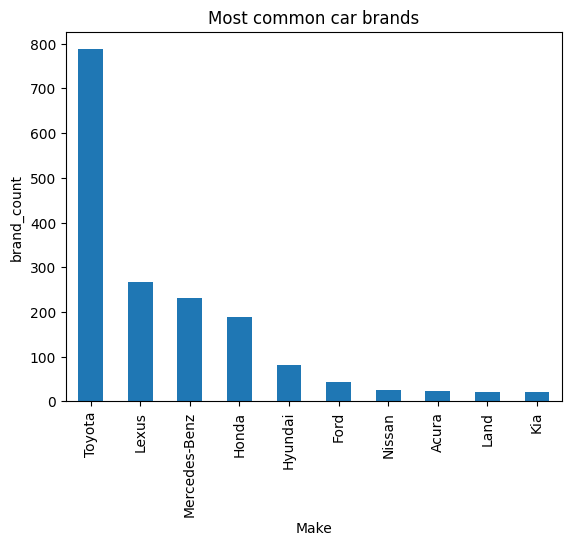

In [21]:
brand_count.head(10).plot(kind='bar')
plt.title('Most common car brands')
plt.xlabel('Make')
plt.ylabel('brand_count')
plt.show()

In [22]:
#What are the most common models per brand?

#For example, which Toyota models appear most frequently?

toyota=new_df[new_df['Make']=="Toyota"]

toyota['Model'].value_counts()

Model
Camry            97
Camry SE         65
Corolla          52
Camry LE         49
Corolla LE       45
                 ..
Camry TRD         1
Yaris LE          1
Tacoma Access     1
Matrix XR         1
Avensis 1         1
Name: count, Length: 92, dtype: int64

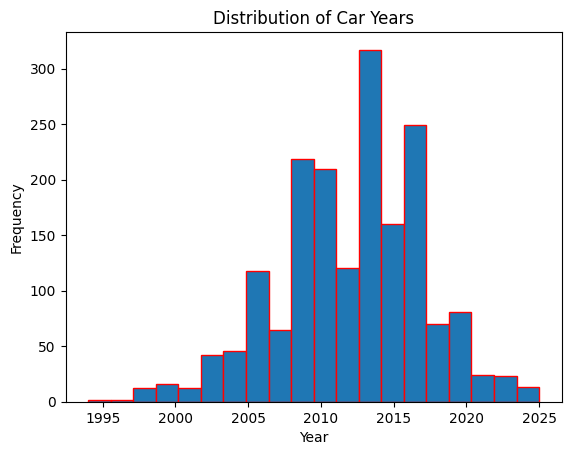

In [23]:
#What’s the distribution of car years?

#Histogram of year shows age distribution of listed cars.

plt.hist(new_df['Year'], bins=20, edgecolor='red')
plt.title('Distribution of Car Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()


In [24]:
#What is the average price by brand and model?
#Compare mean/median price by make and model.

new_df.groupby('Make')['Price'].mean().sort_values(ascending=False)


Make
Chrysler         3.685000e+07
New              3.533571e+07
Porsche          3.200000e+07
Jaguar           3.025000e+07
Jeep             2.925000e+07
Changan          2.800000e+07
Rover            2.800000e+07
GMC              2.717500e+07
Mercedes-Benz    2.259735e+07
Land             2.253545e+07
Volvo            2.016667e+07
ZX               1.800000e+07
Lexus            1.795999e+07
Audi             1.763333e+07
JMC              1.700000e+07
JAC              1.550000e+07
Toyota           1.534192e+07
Ford             1.521455e+07
Subaru           1.500000e+07
Volkswagen       1.498500e+07
BMW              1.410000e+07
Hyundai          1.402757e+07
Mini             1.387500e+07
Dodge            1.327143e+07
Chevrolet        1.215000e+07
Honda            1.145229e+07
Infiniti         1.100000e+07
Acura            1.084526e+07
Mitsubishi       1.013000e+07
Fiat             9.600000e+06
Kia              8.983810e+06
Nissan           8.592000e+06
Mazda            7.871077e+06
Scion

In [25]:
#Which brands are the most expensive on average?
avg_price=new_df.groupby('Make')['Price'].mean().sort_values(ascending=False)

print(avg_price.head(10))


# fig=px.bar(
#     x=avg_price.index,
#     y=avg_price.values,
#     title="Average Price by Brand"
# )

# fig.show()

Make
Chrysler         3.685000e+07
New              3.533571e+07
Porsche          3.200000e+07
Jaguar           3.025000e+07
Jeep             2.925000e+07
Changan          2.800000e+07
Rover            2.800000e+07
GMC              2.717500e+07
Mercedes-Benz    2.259735e+07
Land             2.253545e+07
Name: Price, dtype: float64


In [26]:
median_brand_price = (new_df.groupby('Make')['Price'].median().sort_values(ascending=False))
print(median_brand_price.head(10))

Make
New              40000000.0
Chrysler         36850000.0
Porsche          32000000.0
Jaguar           30250000.0
Jeep             29250000.0
Changan          28000000.0
Rover            28000000.0
GMC              27175000.0
Land             21750000.0
Mercedes-Benz    21250000.0
Name: Price, dtype: float64


In [27]:
#How does car condition affect price?
#Compare “Foreign Used” vs “Local Used” prices.
df.groupby('Condition')['Price'].mean()



Condition
Brand New       3.071102e+08
Foreign Used    3.153874e+07
Local Used      1.319118e+07
Name: Price, dtype: float64

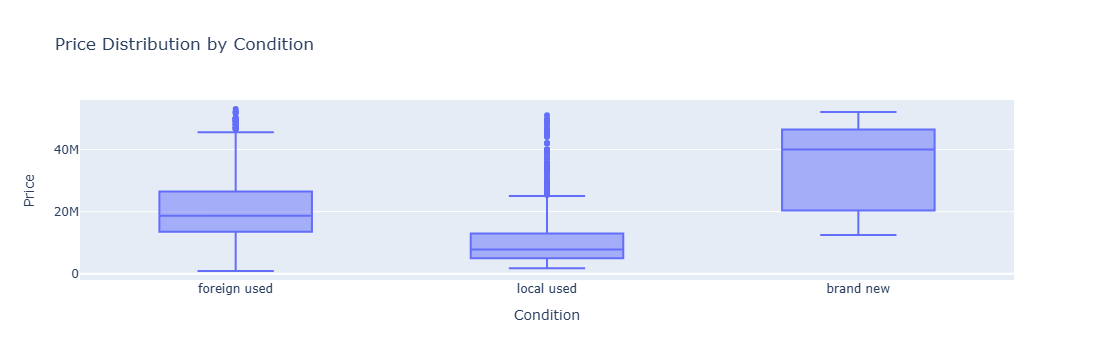

In [28]:
#Boxplot for visual insight
fig=px.box(new_df,
    x='Condition',
    y='Price',
    title='Price Distribution by Condition'
)

fig.show()


In [29]:
#How does transmission type affect price?

#Compare “Automatic” vs “Manual”.

new_df.groupby('Transmission')['Price'].mean()


Transmission
Automatic    1.616964e+07
Manual       8.997362e+06
Name: Price, dtype: float64

In [30]:
new_df['Transmission'].value_counts()

Transmission
Automatic    1758
Manual         43
Name: count, dtype: int64

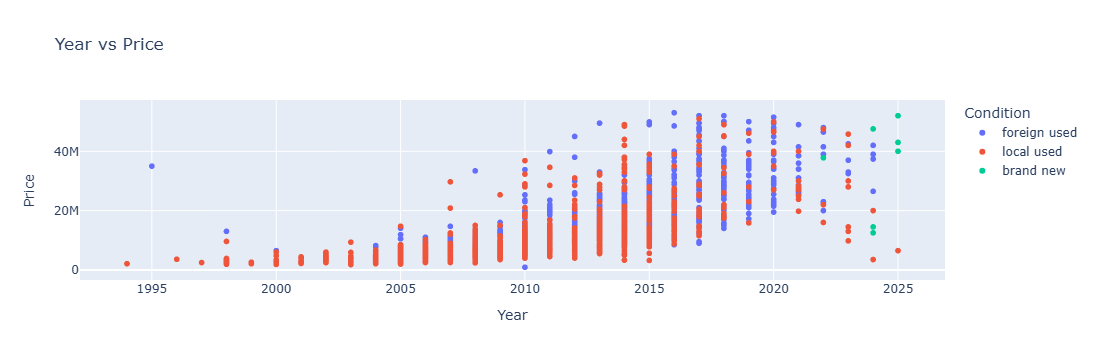

In [31]:
#Are newer cars significantly more expensive?

#Scatterplot of year vs price.
fig=px.scatter(
    new_df,
    x='Year',
    y='Price',
    color='Condition',
    title='Year vs Price'
)

fig.show()

In [32]:
#Correlation coefficient between year and price.
#new_df['Year'].corr(new_df['Price'])
new_df[['Year','Price']].corr()

,Year,Price
Year,1.000000,0.716366
Price,0.716366,1.000000


Summary of Findings
. Brands with the highest average prices: Lexus and Mercedes-Benz typically rank among the most expensive brands, while Toyota often combines high market presence with strong resale value.

. Effect of condition: Foreign Used vehicles generally command higher prices than Local Used vehicles because buyers often perceive them as being in better condition.

. Relationship between year and price: There is usually a positive correlation between manufacturing year and price, meaning newer vehicles tend to sell at higher prices.

. Transmission: Automatic cars are commonly listed more often and usually have higher average prices than manual cars due to stronger consumer demand.

. Model value retention: Premium SUVs and pickup models such as the Toyota Hilux and Lexus RX 350 often retain their value better than many sedan models like the Honda Accord.

Business Insights & Recommendations
. Premium brands such as Lexus, Mercedes-Benz, and Toyota generally perform best in terms of average selling price and market demand.
. Foreign Used vehicles contribute more overall value because they typically have higher prices than Local Used vehicles.
. The highest number of listings is usually concentrated among more recent model years, indicating stronger activity in newer used vehicles.
. Dealers should increase inventory for high-demand brands and models with strong resale values.
. Pricing strategies should account for vehicle condition, transmission type, and manufacturing year to remain competitive.
. Marketing efforts can focus on popular automatic and Foreign Used vehicles while creating promotions for slower-moving Local Used inventory.
. Regular monitoring of pricing trends can help sellers optimize profitability and respond to changes in consumer demand.

In [33]:
new_df.to_csv('data/automation-price-analysis_cleaned_data.csv', index=False)

In [34]:
test_new_df = pd.read_csv('data/automation-price-analysis_cleaned_data.csv')
test_new_df.head()

,Title,Make,Model,Year,Condition,Transmission,Price
0,Lexus Rx 350 Fwd 2017 Blue,Lexus,RX 350,2017,foreign used,Automatic,41000000
1,Toyota Sequoia Sr5 4Dr Suv (4.7L 8Cyl 4A) 2003...,Toyota,Sequoia SR5,2003,local used,Automatic,4650000
2,Toyota Solara 2008 Black,Toyota,Solara,2008,foreign used,Automatic,6600000
3,Toyota Corolla Le 2004 Gray,Toyota,Corolla LE,2004,foreign used,Automatic,7800000
4,Toyota Venza Limited 4Dr Wagon Awd (3.5L 6Cyl ...,Toyota,Venza Limited,2014,local used,Automatic,13000000
